# EDA 11.1: Rating Distribution Analysis

This notebook analyzes the rating distribution, average rating by product and category, whether low ratings align with higher return rates, and leakage-safe historical rating features for explainability or forecasting.

## 1. Setup and File Discovery

Locate required and optional CSV files anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['reviews.csv', 'products.csv', 'returns.csv', 'orders.csv', 'order_items.csv', 'sales.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in ['reviews.csv', 'products.csv', 'returns.csv', 'orders.csv'], 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in ['reviews.csv', 'products.csv', 'returns.csv', 'orders.csv']:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,reviews.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
1,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
2,returns.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
3,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,order_items.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
5,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Reviews, Products, Returns, Orders, and Optional Files

Load all available CSVs safely with pandas and display the raw schemas.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

raw = {name: safe_read_csv(path, name) for name, path in selected_paths.items()}
reviews_raw = raw.get('reviews.csv')
products_raw = raw.get('products.csv')
returns_raw = raw.get('returns.csv')
orders_raw = raw.get('orders.csv')
order_items_raw = raw.get('order_items.csv')
sales_raw = raw.get('sales.csv')

schema_rows = []
for name, df in raw.items():
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded reviews.csv: 113,551 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\reviews.csv
Loaded products.csv: 2,412 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\products.csv
Loaded returns.csv: 39,939 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\returns.csv


Loaded orders.csv: 646,945 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\orders.csv


Loaded order_items.csv: 714,669 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\order_items.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


,file,rows,columns,column_names
0,reviews.csv,113551,7,"review_id, order_id, product_id, customer_id, ..."
1,products.csv,2412,8,"product_id, product_name, category, segment, s..."
2,returns.csv,39939,7,"return_id, order_id, product_id, return_date, ..."
3,orders.csv,646945,8,"order_id, order_date, customer_id, zip, order_..."
4,order_items.csv,714669,7,"order_id, product_id, quantity, unit_price, di..."
5,sales.csv,3833,3,"Date, Revenue, COGS"


## 3. Identify Review, Rating, Product, Category, Order, Return, and Date Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

cols = {}
if reviews_raw is not None:
    cols['review_id'] = find_col(reviews_raw, ['review_id', 'reviewid'], include_all=['review', 'id'])
    cols['rev_product_id'] = find_col(reviews_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['rev_order_id'] = find_col(reviews_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['rev_customer_id'] = find_col(reviews_raw, ['customer_id', 'customerid'], include_all=['customer', 'id'])
    cols['review_date'] = find_col(reviews_raw, ['review_date', 'date', 'created_at'], include_any=['reviewdate', 'date', 'created'])
    cols['rating'] = find_col(reviews_raw, ['rating', 'score', 'stars', 'review_score'], include_any=['rating', 'score', 'stars', 'reviewscore'], prefer_numeric=True)
    cols['review_text'] = find_col(reviews_raw, ['review_text', 'review_title', 'comment', 'text'], include_any=['reviewtext', 'reviewtitle', 'comment', 'text'])
if products_raw is not None:
    cols['prod_product_id'] = find_col(products_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['prod_category'] = find_col(products_raw, ['category', 'product_category'], include_any=['category'])
    cols['prod_segment'] = find_col(products_raw, ['segment', 'product_segment'], include_any=['segment'])
if returns_raw is not None:
    cols['ret_order_id'] = find_col(returns_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['ret_product_id'] = find_col(returns_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['return_date'] = find_col(returns_raw, ['return_date', 'date'], include_any=['returndate', 'date'])
    cols['return_qty'] = find_col(returns_raw, ['return_quantity', 'returned_quantity', 'quantity', 'qty'], include_any=['returnquantity', 'returnedquantity', 'quantity', 'qty'], prefer_numeric=True)
    cols['refund_amount'] = find_col(returns_raw, ['refund_amount', 'refund_value', 'refund', 'amount'], include_any=['refundamount', 'refundvalue', 'refund'], exclude_any=['id'], prefer_numeric=True)
if orders_raw is not None:
    cols['orders_order_id'] = find_col(orders_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['orders_date'] = find_col(orders_raw, ['order_date', 'date'], include_any=['orderdate', 'date'])
    cols['orders_customer_id'] = find_col(orders_raw, ['customer_id', 'customerid'], include_all=['customer', 'id'])
if order_items_raw is not None:
    cols['oi_order_id'] = find_col(order_items_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['oi_product_id'] = find_col(order_items_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['oi_qty'] = find_col(order_items_raw, ['quantity', 'qty', 'units_sold'], include_any=['quantity', 'qty', 'unitssold'], prefer_numeric=True)
if sales_raw is not None:
    cols['sales_date'] = find_col(sales_raw, ['date', 'sales_date', 'order_date'], include_any=['date'])

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)

,role,column
0,review_id,review_id
1,rev_product_id,product_id
2,rev_order_id,order_id
3,rev_customer_id,customer_id
4,review_date,review_date
5,rating,rating
6,review_text,review_title
7,prod_product_id,product_id
8,prod_category,category
9,prod_segment,segment


## 4. Reviews Data Quality Checks

Inspect rating coverage, invalid scores, missing keys, duplicate reviews, and summary statistics.

In [4]:
reviews_df = pd.DataFrame()
rating_warnings = []

if reviews_raw is None or reviews_raw.empty:
    rating_warnings.append('reviews.csv is missing or empty.')
else:
    reviews_df = reviews_raw.copy()
    reviews_df['review_id_std'] = reviews_df[cols['review_id']].astype('string').str.strip() if cols.get('review_id') else pd.NA
    reviews_df['product_id_std'] = reviews_df[cols['rev_product_id']].astype('string').str.strip() if cols.get('rev_product_id') else pd.NA
    reviews_df['order_id_std'] = reviews_df[cols['rev_order_id']].astype('string').str.strip() if cols.get('rev_order_id') else pd.NA
    reviews_df['customer_id_std'] = reviews_df[cols['rev_customer_id']].astype('string').str.strip() if cols.get('rev_customer_id') else pd.NA
    reviews_df['review_date_std'] = pd.to_datetime(reviews_df[cols['review_date']], errors='coerce').dt.floor('D') if cols.get('review_date') else pd.NaT
    reviews_df['rating_std'] = to_num(reviews_df[cols['rating']]) if cols.get('rating') else np.nan
    if cols.get('rating') is None:
        rating_warnings.append('Rating column could not be identified.')

    valid_ratings = reviews_df['rating_std'].dropna()
    invalid_ratings = reviews_df.loc[~reviews_df['rating_std'].between(1, 5, inclusive='both') & reviews_df['rating_std'].notna(), ['review_id_std', 'rating_std']]
    report = pd.DataFrame([
        {'metric': 'review_rows', 'value': len(reviews_df)},
        {'metric': 'review_date_range_start', 'value': reviews_df['review_date_std'].min()},
        {'metric': 'review_date_range_end', 'value': reviews_df['review_date_std'].max()},
        {'metric': 'missing_ratings', 'value': int(reviews_df['rating_std'].isna().sum())},
        {'metric': 'invalid_ratings_outside_1_to_5', 'value': int(len(invalid_ratings))},
        {'metric': 'missing_product_ids', 'value': int(reviews_df['product_id_std'].isna().sum())},
        {'metric': 'missing_order_ids', 'value': int(reviews_df['order_id_std'].isna().sum())},
        {'metric': 'duplicate_review_records', 'value': int(reviews_df.duplicated(['review_id_std']).sum()) if 'review_id_std' in reviews_df else np.nan},
    ])
    display(report)
    if valid_ratings.notna().sum() > 0:
        rating_stats = pd.DataFrame([{
            'count': valid_ratings.count(),
            'mean': valid_ratings.mean(),
            'median': valid_ratings.median(),
            'std': valid_ratings.std(),
            'min': valid_ratings.min(),
            'max': valid_ratings.max(),
            'p10': valid_ratings.quantile(0.10),
            'p25': valid_ratings.quantile(0.25),
            'p75': valid_ratings.quantile(0.75),
            'p90': valid_ratings.quantile(0.90),
        }])
        display(rating_stats)
    if not invalid_ratings.empty:
        print('Invalid rating examples:')
        display(invalid_ratings.head(20))
    display(reviews_df.head())

if rating_warnings:
    print('Rating warnings:')
    for w in rating_warnings:
        print('-', w)

,metric,value
0,review_rows,113551
1,review_date_range_start,2012-07-10 00:00:00
2,review_date_range_end,2022-12-31 00:00:00
3,missing_ratings,0
4,invalid_ratings_outside_1_to_5,0
5,missing_product_ids,0
6,missing_order_ids,0
7,duplicate_review_records,0


,count,mean,median,std,min,max,p10,p25,p75,p90
0,113551,3.9360,4.0000,1.1499,1,5,2.0000,3.0000,5.0000,5.0000


,review_id,order_id,product_id,customer_id,review_date,rating,review_title,review_id_std,product_id_std,order_id_std,customer_id_std,review_date_std,rating_std
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend,REV-0000001,2400,1,58578,2012-07-24,5
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied,REV-0000002,396,3,58811,2012-08-03,5
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality,REV-0000003,1431,10,49101,2012-07-23,5
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality,REV-0000005,1668,16,41028,2012-08-05,5
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall,REV-0000006,2352,17,42030,2012-07-17,4


## 5. Build Review-Enriched Product Dataset

Join reviews with products and orders, keep relevant columns, and report join quality.

In [5]:
reviews_enriched = pd.DataFrame()
join_quality = pd.DataFrame()

if reviews_df.empty:
    print('Reviews data is unavailable; enriched review dataset cannot be built.')
else:
    reviews_enriched = reviews_df.copy()
    matched_products = np.nan
    matched_orders = np.nan
    if products_raw is not None and cols.get('prod_product_id'):
        prod = products_raw.copy()
        prod['product_id_std'] = prod[cols['prod_product_id']].astype('string').str.strip()
        prod_keep = ['product_id_std']
        for c in [cols.get('prod_category'), cols.get('prod_segment')]:
            if c and c not in prod_keep:
                prod_keep.append(c)
        prod = prod[prod_keep].drop_duplicates('product_id_std')
        product_set = set(prod['product_id_std'].dropna())
        matched_products = int(reviews_enriched['product_id_std'].isin(product_set).sum())
        reviews_enriched = reviews_enriched.merge(prod, on='product_id_std', how='left', suffixes=('', '_prod'))
    if cols.get('prod_category') and cols.get('prod_category') in reviews_enriched.columns:
        reviews_enriched['category_final'] = reviews_enriched[cols['prod_category']].astype('string').fillna('Unknown')
    else:
        reviews_enriched['category_final'] = 'Unknown'
        rating_warnings.append('Product category could not be joined; category-level rating analysis cannot be fully performed.')
    if cols.get('prod_segment') and cols.get('prod_segment') in reviews_enriched.columns:
        reviews_enriched['segment_final'] = reviews_enriched[cols['prod_segment']].astype('string').fillna('Unknown')
    else:
        reviews_enriched['segment_final'] = pd.NA

    if orders_raw is not None and cols.get('orders_order_id') and cols.get('rev_order_id'):
        od = orders_raw.copy()
        od['order_id_std'] = od[cols['orders_order_id']].astype('string').str.strip()
        od['order_date_std'] = pd.to_datetime(od[cols['orders_date']], errors='coerce').dt.floor('D') if cols.get('orders_date') else pd.NaT
        od['orders_customer_id_std'] = od[cols['orders_customer_id']].astype('string').str.strip() if cols.get('orders_customer_id') else pd.NA
        matched_orders = int(reviews_enriched['order_id_std'].isin(set(od['order_id_std'].dropna())).sum())
        reviews_enriched = reviews_enriched.merge(od[['order_id_std', 'order_date_std', 'orders_customer_id_std']], on='order_id_std', how='left')

    join_quality = pd.DataFrame([
        {'metric': 'reviews_matched_to_products', 'value': matched_products},
        {'metric': 'reviews_unmatched_to_products', 'value': int(len(reviews_enriched) - matched_products) if pd.notna(matched_products) else np.nan},
        {'metric': 'reviews_matched_to_orders', 'value': matched_orders},
        {'metric': 'duplicate_review_ids', 'value': int(reviews_enriched.duplicated(['review_id_std']).sum()) if 'review_id_std' in reviews_enriched else np.nan},
    ])
    display(join_quality)
    unmatched_reviews = reviews_enriched.loc[reviews_enriched['category_final'].eq('Unknown'), ['review_id_std', 'product_id_std']].head(20)
    if not unmatched_reviews.empty:
        print('Sample unmatched review-product records:')
        display(unmatched_reviews)
    keep_cols = [c for c in ['review_id_std', 'product_id_std', 'order_id_std', 'customer_id_std', 'review_date_std', 'rating_std', 'category_final', 'segment_final', 'order_date_std'] if c in reviews_enriched.columns]
    display(reviews_enriched[keep_cols].head(20))

,metric,value
0,reviews_matched_to_products,113551
1,reviews_unmatched_to_products,0
2,reviews_matched_to_orders,113551
3,duplicate_review_ids,0


,review_id_std,product_id_std,order_id_std,customer_id_std,review_date_std,rating_std,category_final,segment_final,order_date_std
0,REV-0000001,2400,1,58578,2012-07-24,5,GenZ,Trendy,2012-07-04
1,REV-0000002,396,3,58811,2012-08-03,5,Streetwear,Balanced,2012-07-04
2,REV-0000003,1431,10,49101,2012-07-23,5,Outdoor,Activewear,2012-07-06
3,REV-0000005,1668,16,41028,2012-08-05,5,Streetwear,Standard,2012-07-05
4,REV-0000006,2352,17,42030,2012-07-17,4,Streetwear,Performance,2012-07-05
5,REV-0000008,2241,20,42962,2012-08-12,5,Outdoor,Activewear,2012-07-04
6,REV-0000009,1041,23,12213,2012-07-19,5,Streetwear,Everyday,2012-07-06
7,REV-0000010,671,24,13426,2012-08-09,4,Streetwear,Everyday,2012-07-05
8,REV-0000011,396,28,9473,2012-07-27,5,Streetwear,Balanced,2012-07-06
9,REV-0000012,671,49,39696,2012-07-17,5,Streetwear,Everyday,2012-07-04


## 6. Rating Distribution

Calculate overall rating distribution and low/high rating shares. The low-rating threshold used here is `rating <= 2`.

,rating,count,share
0,1,5772,0.0508
1,2,9095,0.0801
2,3,17016,0.1499
3,4,36412,0.3207
4,5,45256,0.3986


Average rating: 3.9360
Median rating: 4.0000
Low rating ratio (<= 2): 13.09%
High rating ratio (>= 4): 71.92%


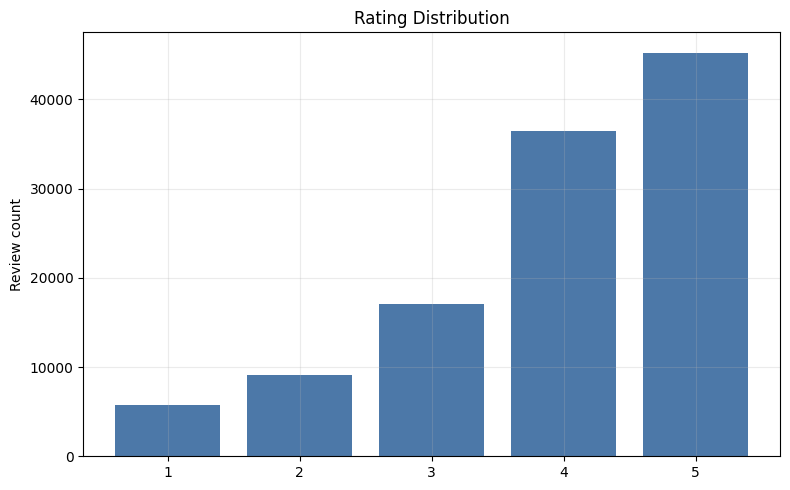

In [6]:
rating_distribution = pd.DataFrame()
low_rating_threshold = 2
high_rating_threshold = 4
avg_rating = np.nan
median_rating = np.nan
low_rating_ratio = np.nan
high_rating_ratio = np.nan

if reviews_enriched.empty or reviews_enriched['rating_std'].dropna().empty:
    print('Rating distribution cannot be computed because rating data is unavailable.')
else:
    valid = reviews_enriched.loc[reviews_enriched['rating_std'].between(1, 5, inclusive='both')].copy()
    rating_distribution = valid['rating_std'].value_counts().sort_index().rename_axis('rating').reset_index(name='count')
    rating_distribution['share'] = rating_distribution['count'] / rating_distribution['count'].sum()
    avg_rating = valid['rating_std'].mean()
    median_rating = valid['rating_std'].median()
    low_rating_ratio = (valid['rating_std'] <= low_rating_threshold).mean()
    high_rating_ratio = (valid['rating_std'] >= high_rating_threshold).mean()
    display(rating_distribution)
    print(f'Average rating: {avg_rating:,.4f}')
    print(f'Median rating: {median_rating:,.4f}')
    print(f'Low rating ratio (<= {low_rating_threshold}): {low_rating_ratio:.2%}')
    print(f'High rating ratio (>= {high_rating_threshold}): {high_rating_ratio:.2%}')

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(rating_distribution['rating'].astype(str), rating_distribution['count'], color='#4C78A8')
    ax.set_title('Rating Distribution')
    ax.set_ylabel('Review count')
    plt.tight_layout()
    plt.show()

## 7. Average Rating by Category

Aggregate rating metrics by category and identify low-rated categories with adequate review volume.

,category_final,review_count,average_rating,median_rating,low_rating_count,low_rating_ratio,high_rating_ratio,rating_std,small_sample_flag
1,GenZ,5792,3.9228,4.0000,765,0.1321,0.7125,1.1497,False
0,Casual,3790,3.9232,4.0000,520,0.1372,0.7182,1.1632,True
2,Outdoor,41265,3.9339,4.0000,5411,0.1311,0.7166,1.1529,False
3,Streetwear,62704,3.9394,4.0000,8171,0.1303,0.7216,1.1471,False


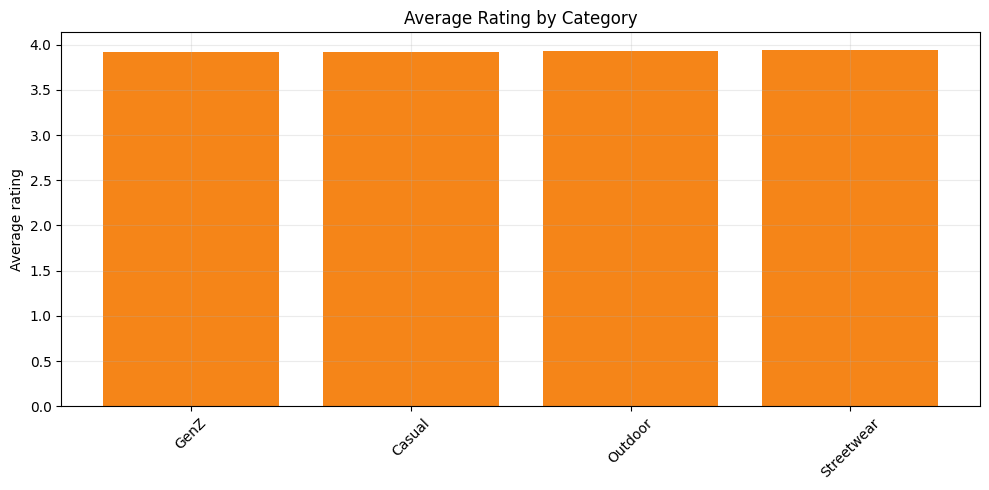

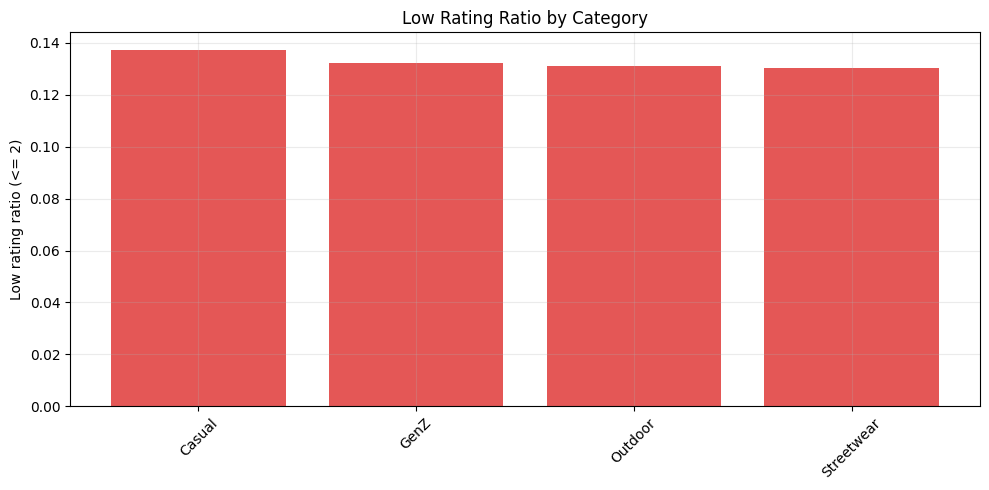

In [7]:
category_rating = pd.DataFrame()
if reviews_enriched.empty or 'category_final' not in reviews_enriched.columns or reviews_enriched['rating_std'].dropna().empty:
    print('Category rating analysis cannot be computed.')
else:
    valid = reviews_enriched.loc[reviews_enriched['rating_std'].between(1, 5, inclusive='both')].copy()
    category_rating = valid.groupby('category_final').agg(
        review_count=('rating_std', 'count'),
        average_rating=('rating_std', 'mean'),
        median_rating=('rating_std', 'median'),
        low_rating_count=('rating_std', lambda s: int((s <= low_rating_threshold).sum())),
        low_rating_ratio=('rating_std', lambda s: (s <= low_rating_threshold).mean()),
        high_rating_ratio=('rating_std', lambda s: (s >= high_rating_threshold).mean()),
        rating_std=('rating_std', 'std'),
    ).reset_index()
    category_rating['small_sample_flag'] = category_rating['review_count'] < max(20, category_rating['review_count'].quantile(0.1))
    display(category_rating.sort_values(['average_rating', 'low_rating_ratio'], ascending=[True, False]))

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = category_rating.sort_values('average_rating')
    ax.bar(plot_df['category_final'].astype(str), plot_df['average_rating'], color='#F58518')
    ax.set_title('Average Rating by Category')
    ax.set_ylabel('Average rating')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = category_rating.sort_values('low_rating_ratio', ascending=False)
    ax.bar(plot_df['category_final'].astype(str), plot_df['low_rating_ratio'], color='#E45756')
    ax.set_title('Low Rating Ratio by Category')
    ax.set_ylabel(f'Low rating ratio (<= {low_rating_threshold})')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Rating by Product and Segment

Identify low-rated products with enough review volume and summarize segment-level rating patterns when segment exists.

,product_id_std,review_count,average_rating,low_rating_ratio,category_final,segment_final
1368,940,35,3.3143,0.2571,Streetwear,Everyday
693,2069,22,3.3182,0.3182,Streetwear,Everyday
1393,974,28,3.3214,0.2143,Streetwear,Everyday
224,1340,20,3.3500,0.2500,Outdoor,Activewear
777,2202,31,3.3548,0.3548,Casual,All-weather
103,1141,32,3.4062,0.2812,Streetwear,Balanced
569,1875,41,3.4146,0.2927,Streetwear,Balanced
206,1308,21,3.4286,0.2381,Casual,All-weather
1229,669,39,3.4359,0.1795,Streetwear,Everyday
560,1863,25,3.4400,0.2800,Streetwear,Balanced


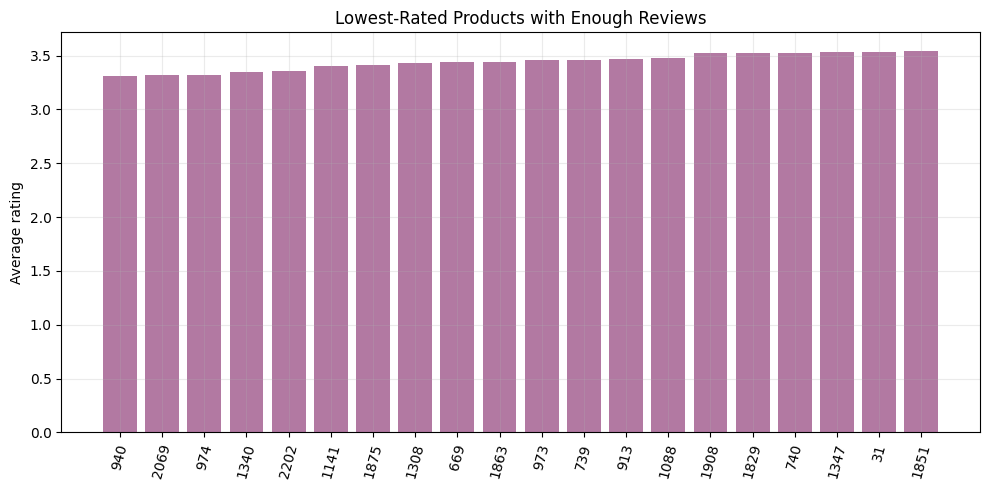

,segment_final,review_count,average_rating,low_rating_ratio
7,Trendy,5792,3.9228,0.1321
6,Standard,1707,3.9274,0.1271
1,All-weather,3558,3.9275,0.1372
0,Activewear,36600,3.9299,0.1319
2,Balanced,16387,3.9331,0.1318
4,Performance,15447,3.9372,0.1319
3,Everyday,29163,3.9448,0.1289
5,Premium,4897,3.9604,0.1258


In [8]:
product_rating = pd.DataFrame()
segment_rating = pd.DataFrame()
if reviews_enriched.empty or reviews_enriched['rating_std'].dropna().empty:
    print('Product and segment rating analysis cannot be computed.')
else:
    valid = reviews_enriched.loc[reviews_enriched['rating_std'].between(1, 5, inclusive='both')].copy()
    product_rating = valid.groupby('product_id_std').agg(
        review_count=('rating_std', 'count'),
        average_rating=('rating_std', 'mean'),
        low_rating_ratio=('rating_std', lambda s: (s <= low_rating_threshold).mean()),
        category_final=('category_final', 'first'),
        segment_final=('segment_final', 'first'),
    ).reset_index()
    min_reviews = max(10, int(product_rating['review_count'].quantile(0.5))) if not product_rating.empty else 10
    low_rated_products = product_rating[product_rating['review_count'] >= min_reviews].sort_values(['average_rating', 'low_rating_ratio'], ascending=[True, False]).head(20)
    display(low_rated_products)

    if not low_rated_products.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(low_rated_products['product_id_std'].astype(str), low_rated_products['average_rating'], color='#B279A2')
        ax.set_title('Lowest-Rated Products with Enough Reviews')
        ax.set_ylabel('Average rating')
        ax.tick_params(axis='x', rotation=75)
        plt.tight_layout()
        plt.show()

    if 'segment_final' in valid.columns and valid['segment_final'].notna().sum() > 0:
        segment_rating = valid.dropna(subset=['segment_final']).groupby('segment_final').agg(
            review_count=('rating_std', 'count'),
            average_rating=('rating_std', 'mean'),
            low_rating_ratio=('rating_std', lambda s: (s <= low_rating_threshold).mean()),
        ).reset_index().sort_values(['average_rating', 'low_rating_ratio'], ascending=[True, False])
        display(segment_rating)

## 9. Return Rate Preparation

Prepare return rates at the most reliable available granularity. Exact `order_id + product_id` matching is preferred; product-level or category-level aggregates are derived from that matched dataset.

In [9]:
return_rates_product = pd.DataFrame()
return_rates_category = pd.DataFrame()
return_match_strategy = 'unavailable'

if returns_raw is None or returns_raw.empty or order_items_raw is None or order_items_raw.empty:
    print('Returns or order_items data is unavailable; return-rate preparation cannot be fully performed.')
else:
    ret = returns_raw.copy()
    ret['order_id_std'] = ret[cols['ret_order_id']].astype('string').str.strip() if cols.get('ret_order_id') else pd.NA
    ret['product_id_std'] = ret[cols['ret_product_id']].astype('string').str.strip() if cols.get('ret_product_id') else pd.NA
    ret['returned_quantity_std'] = to_num(ret[cols['return_qty']]) if cols.get('return_qty') else 1
    ret['refund_amount_std'] = to_num(ret[cols['refund_amount']]) if cols.get('refund_amount') else np.nan
    oi = order_items_raw.copy()
    oi['order_id_std'] = oi[cols['oi_order_id']].astype('string').str.strip() if cols.get('oi_order_id') else pd.NA
    oi['product_id_std'] = oi[cols['oi_product_id']].astype('string').str.strip() if cols.get('oi_product_id') else pd.NA
    oi['ordered_quantity'] = to_num(oi[cols['oi_qty']]) if cols.get('oi_qty') else 1

    if reviews_enriched.empty:
        prod_map = pd.DataFrame()
    else:
        prod_map = reviews_enriched[['product_id_std', 'category_final']].drop_duplicates()
    if ret['order_id_std'].notna().sum() > 0 and ret['product_id_std'].notna().sum() > 0:
        ret_key = ret.groupby(['order_id_std', 'product_id_std'], as_index=False).agg(
            returned_quantity=('returned_quantity_std', 'sum'),
            return_count=('returned_quantity_std', 'count'),
        )
        oi_key = oi.groupby(['order_id_std', 'product_id_std'], as_index=False).agg(
            ordered_quantity=('ordered_quantity', 'sum'),
            order_line_count=('ordered_quantity', 'count'),
        )
        linked = oi_key.merge(ret_key, on=['order_id_std', 'product_id_std'], how='left')
        linked['returned_quantity'] = linked['returned_quantity'].fillna(0)
        linked['return_indicator'] = linked['returned_quantity'] > 0
        return_match_strategy = 'exact order_id + product_id'
    elif ret['order_id_std'].notna().sum() > 0:
        ret_key = ret.groupby('order_id_std', as_index=False).agg(
            returned_quantity=('returned_quantity_std', 'sum'),
            return_count=('returned_quantity_std', 'count'),
        )
        oi_key = oi.groupby('order_id_std', as_index=False).agg(
            ordered_quantity=('ordered_quantity', 'sum'),
            order_line_count=('ordered_quantity', 'count'),
        )
        linked = oi_key.merge(ret_key, on='order_id_std', how='left')
        linked['returned_quantity'] = linked['returned_quantity'].fillna(0)
        linked['return_indicator'] = linked['returned_quantity'] > 0
        return_match_strategy = 'approximate order_id only'
        rating_warnings.append('Return matching for rating analysis is approximate because product-level keys were not fully available.')
    else:
        linked = pd.DataFrame()
        rating_warnings.append('Returns could not be reliably linked to products or orders; rating-vs-return analysis may be skipped.')

    if not linked.empty:
        if 'product_id_std' in linked.columns and not prod_map.empty:
            linked = linked.merge(prod_map, on='product_id_std', how='left')
        return_rates_product = linked.groupby('product_id_std').agg(
            ordered_quantity=('ordered_quantity', 'sum'),
            returned_quantity=('returned_quantity', 'sum'),
            return_rate=('return_indicator', 'mean'),
        ).reset_index()
        if 'category_final' in linked.columns:
            return_rates_category = linked.groupby('category_final').agg(
                ordered_quantity=('ordered_quantity', 'sum'),
                returned_quantity=('returned_quantity', 'sum'),
                return_rate=('return_indicator', 'mean'),
            ).reset_index()
    print('Return matching strategy used for rating-vs-return analysis:')
    print(return_match_strategy)

Return matching strategy used for rating-vs-return analysis:
exact order_id + product_id


## 10. Rating vs Return Rate

Analyze whether lower ratings align with higher return rates at product and category level. Correlation does not imply causation.

,level,metric_x,metric_y,correlation
0,product,average_rating,return_rate,-0.0990
1,product,low_rating_ratio,return_rate,0.1051
2,category,average_rating,return_rate,0.0641
3,category,low_rating_ratio,return_rate,-0.7193


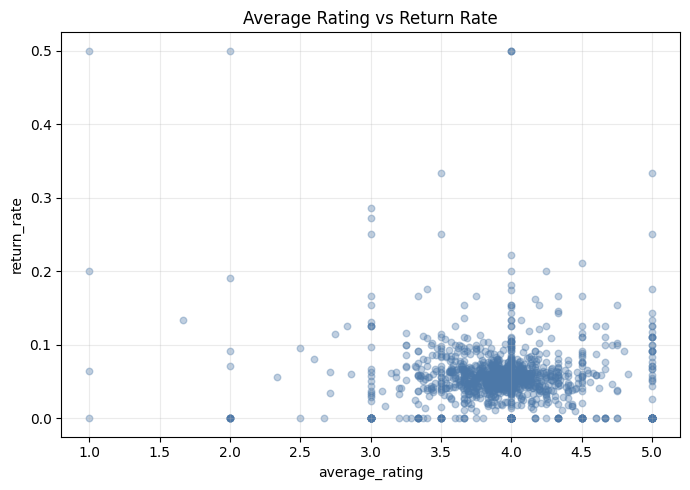

,product_id_std,category_final,review_count,average_rating,low_rating_ratio,return_rate
1368,940,Streetwear,35,3.3143,0.2571,0.0704
693,2069,Streetwear,22,3.3182,0.3182,0.0250
1393,974,Streetwear,28,3.3214,0.2143,0.0692
224,1340,Outdoor,20,3.3500,0.2500,0.0543
777,2202,Casual,31,3.3548,0.3548,0.0577
103,1141,Streetwear,32,3.4062,0.2812,0.0563
569,1875,Streetwear,41,3.4146,0.2927,0.0562
206,1308,Casual,21,3.4286,0.2381,0.0392
1229,669,Streetwear,39,3.4359,0.1795,0.1020
560,1863,Streetwear,25,3.4400,0.2800,0.0427


In [10]:
rating_return_corr = pd.DataFrame()
low_rating_high_return = pd.DataFrame()
if product_rating.empty or return_rates_product.empty:
    print('Rating vs return-rate analysis cannot be fully computed because review or return aggregates are unavailable.')
else:
    product_join = product_rating.merge(return_rates_product, on='product_id_std', how='inner')
    corr_rows = []
    valid = product_join[['average_rating', 'return_rate']].dropna()
    if len(valid) >= 2:
        corr_rows.append({'level': 'product', 'metric_x': 'average_rating', 'metric_y': 'return_rate', 'correlation': valid['average_rating'].corr(valid['return_rate'])})
        valid2 = product_join[['low_rating_ratio', 'return_rate']].dropna()
        if len(valid2) >= 2:
            corr_rows.append({'level': 'product', 'metric_x': 'low_rating_ratio', 'metric_y': 'return_rate', 'correlation': valid2['low_rating_ratio'].corr(valid2['return_rate'])})

    if not category_rating.empty and not return_rates_category.empty:
        category_join = category_rating.merge(return_rates_category, on='category_final', how='inner')
        valid = category_join[['average_rating', 'return_rate']].dropna()
        if len(valid) >= 2:
            corr_rows.append({'level': 'category', 'metric_x': 'average_rating', 'metric_y': 'return_rate', 'correlation': valid['average_rating'].corr(valid['return_rate'])})
            valid2 = category_join[['low_rating_ratio', 'return_rate']].dropna()
            if len(valid2) >= 2:
                corr_rows.append({'level': 'category', 'metric_x': 'low_rating_ratio', 'metric_y': 'return_rate', 'correlation': valid2['low_rating_ratio'].corr(valid2['return_rate'])})
    rating_return_corr = pd.DataFrame(corr_rows)
    display(rating_return_corr)

    fig, ax = plt.subplots(figsize=(7, 5))
    sample = product_join[['average_rating', 'return_rate']].dropna()
    ax.scatter(sample['average_rating'], sample['return_rate'], alpha=0.35, s=22, color='#4C78A8')
    ax.set_title('Average Rating vs Return Rate')
    ax.set_xlabel('average_rating')
    ax.set_ylabel('return_rate')
    plt.tight_layout()
    plt.show()

    low_rating_high_return = product_join[(product_join['review_count'] >= max(10, product_join['review_count'].quantile(0.5)))].sort_values(['average_rating', 'return_rate'], ascending=[True, False]).head(20)
    display(low_rating_high_return[['product_id_std', 'category_final', 'review_count', 'average_rating', 'low_rating_ratio', 'return_rate']])

## 11. Rating Trend Over Time

Aggregate reviews by month and inspect average rating, review count, and low-rating ratio over time.

,year_month,review_count,avg_rating,low_rating_count,low_rating_ratio,high_rating_ratio,month_start
0,2012-07,220,4.0136,24,0.1091,0.7773,2012-07-01
1,2012-08,1085,3.9558,146,0.1346,0.7290,2012-08-01
2,2012-09,1069,3.9429,133,0.1244,0.7240,2012-09-01
3,2012-10,890,3.9281,122,0.1371,0.7315,2012-10-01
4,2012-11,760,3.9671,107,0.1408,0.7303,2012-11-01
...,...,...,...,...,...,...,...
121,2022-08,482,3.9481,57,0.1183,0.7116,2022-08-01
122,2022-09,511,3.9080,69,0.1350,0.7319,2022-09-01
123,2022-10,422,3.8886,61,0.1445,0.7014,2022-10-01
124,2022-11,329,3.8997,41,0.1246,0.6900,2022-11-01


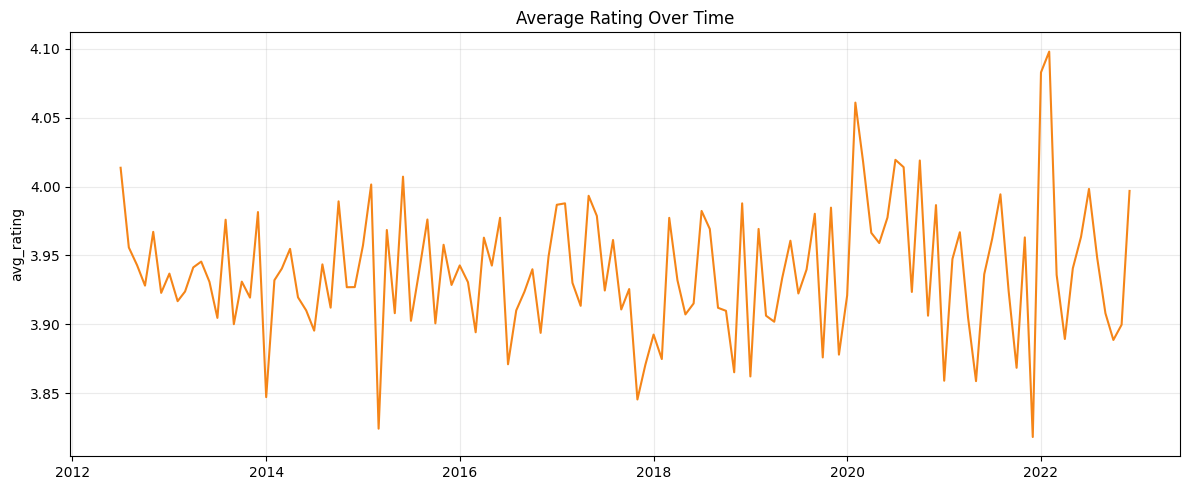

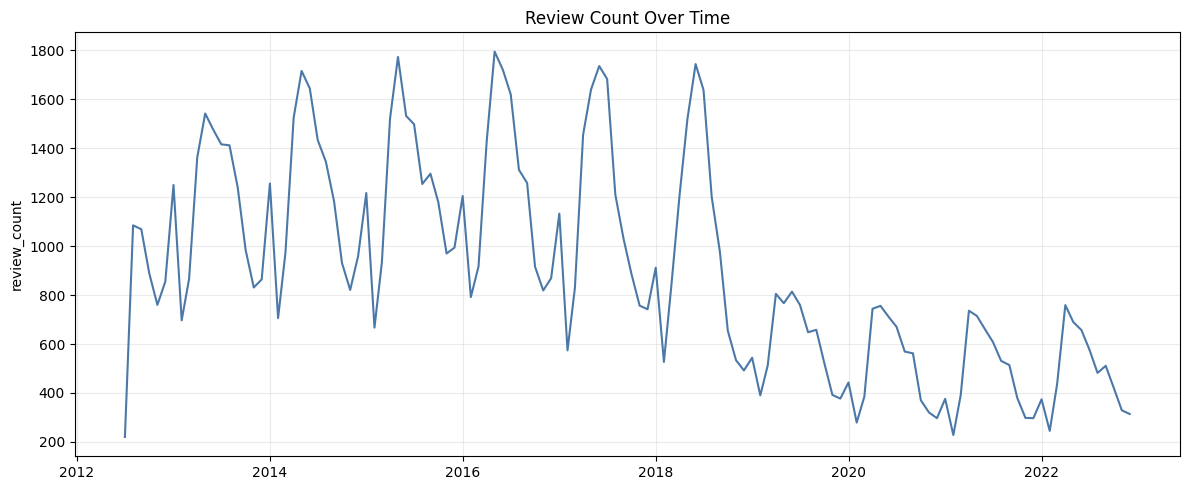

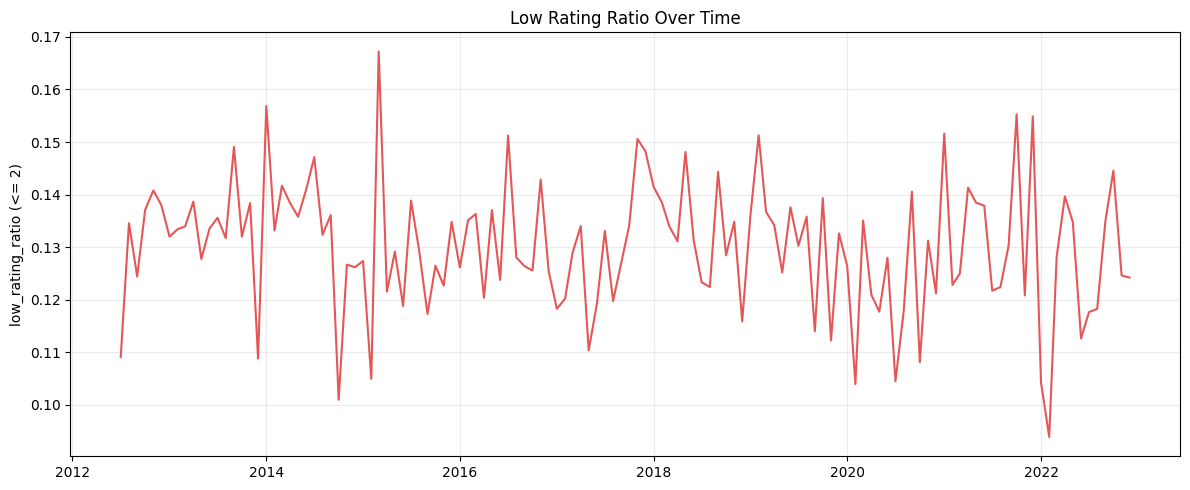

In [11]:
rating_monthly = pd.DataFrame()
if reviews_enriched.empty or pd.Series(reviews_enriched['review_date_std']).isna().all() or reviews_enriched['rating_std'].dropna().empty:
    print('Rating trend over time cannot be computed because review dates or ratings are unavailable.')
else:
    temp = reviews_enriched.loc[reviews_enriched['rating_std'].between(1, 5, inclusive='both')].dropna(subset=['review_date_std']).copy()
    temp['year_month'] = temp['review_date_std'].dt.to_period('M').astype('string')
    rating_monthly = temp.groupby('year_month').agg(
        review_count=('rating_std', 'count'),
        avg_rating=('rating_std', 'mean'),
        low_rating_count=('rating_std', lambda s: int((s <= low_rating_threshold).sum())),
        low_rating_ratio=('rating_std', lambda s: (s <= low_rating_threshold).mean()),
        high_rating_ratio=('rating_std', lambda s: (s >= high_rating_threshold).mean()),
    ).reset_index()
    rating_monthly['month_start'] = pd.PeriodIndex(rating_monthly['year_month'], freq='M').to_timestamp()
    display(rating_monthly)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(rating_monthly['month_start'], rating_monthly['avg_rating'], color='#F58518')
    ax.set_title('Average Rating Over Time')
    ax.set_ylabel('avg_rating')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(rating_monthly['month_start'], rating_monthly['review_count'], color='#4C78A8')
    ax.set_title('Review Count Over Time')
    ax.set_ylabel('review_count')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(rating_monthly['month_start'], rating_monthly['low_rating_ratio'], color='#E45756')
    ax.set_title('Low Rating Ratio Over Time')
    ax.set_ylabel(f'low_rating_ratio (<= {low_rating_threshold})')
    plt.tight_layout()
    plt.show()

## 12. Leakage-Safe Review/Rating Forecast Feature Preview

Create historical review aggregates only. Future reviews and ratings are not used directly for forecasting.

In [12]:
feature_preview = pd.DataFrame()
feature_registry = pd.DataFrame()
if rating_monthly.empty:
    print('Monthly review aggregates are unavailable; forecast feature preview cannot be built.')
else:
    feature_preview = rating_monthly.sort_values('month_start').copy()
    feature_preview['avg_rating_lag'] = feature_preview['avg_rating'].shift(1)
    feature_preview['low_rating_ratio_lag'] = feature_preview['low_rating_ratio'].shift(1)
    feature_preview['review_count_lag'] = feature_preview['review_count'].shift(1)
    feature_preview['avg_rating_roll_mean_3m'] = feature_preview['avg_rating'].shift(1).rolling(3, min_periods=2).mean()
    feature_preview['low_rating_ratio_roll_mean_3m'] = feature_preview['low_rating_ratio'].shift(1).rolling(3, min_periods=2).mean()
    feature_preview['review_count_roll_sum_3m'] = feature_preview['review_count'].shift(1).rolling(3, min_periods=2).sum()
    if not reviews_enriched.empty and 'category_final' in reviews_enriched.columns:
        cat_month = reviews_enriched.loc[reviews_enriched['rating_std'].between(1, 5, inclusive='both')].dropna(subset=['review_date_std']).copy()
        cat_month['year_month'] = cat_month['review_date_std'].dt.to_period('M').astype('string')
        cat_pressure = cat_month.groupby(['year_month', 'category_final']).agg(low_rating_ratio=('rating_std', lambda s: (s <= low_rating_threshold).mean())).reset_index()
        max_cat_pressure = cat_pressure.groupby('year_month')['low_rating_ratio'].max().reset_index(name='category_low_rating_pressure')
        feature_preview = feature_preview.merge(max_cat_pressure, on='year_month', how='left')
        feature_preview['category_low_rating_pressure_lag'] = feature_preview['category_low_rating_pressure'].shift(1)

    preview_cols = ['month_start', 'avg_rating', 'review_count', 'low_rating_count', 'low_rating_ratio', 'high_rating_ratio', 'avg_rating_lag', 'low_rating_ratio_lag', 'review_count_lag', 'avg_rating_roll_mean_3m', 'low_rating_ratio_roll_mean_3m', 'review_count_roll_sum_3m']
    if 'category_low_rating_pressure_lag' in feature_preview.columns:
        preview_cols.append('category_low_rating_pressure_lag')
    display(feature_preview[preview_cols].head(24))

    same_month_known_only = ['avg_rating', 'review_count', 'low_rating_ratio', 'high_rating_ratio']
    historical_safe = [c for c in feature_preview.columns if c.endswith('_lag') or c.endswith('_3m')]
    feature_registry = pd.DataFrame({
        'feature': same_month_known_only + historical_safe,
        'feature_type': ['requires known current-period reviews'] * len(same_month_known_only) + ['historical lagged/rolling only'] * len(historical_safe),
        'forecast_use_note': ['Use only if current-period reviews are genuinely known before prediction.'] * len(same_month_known_only) + ['Leakage-safe because the feature uses only prior realized review history.'] * len(historical_safe),
    })
    display(feature_registry)

,month_start,avg_rating,review_count,low_rating_count,low_rating_ratio,high_rating_ratio,avg_rating_lag,low_rating_ratio_lag,review_count_lag,avg_rating_roll_mean_3m,low_rating_ratio_roll_mean_3m,review_count_roll_sum_3m,category_low_rating_pressure_lag
0,2012-07-01,4.0136,220,24,0.1091,0.7773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-08-01,3.9558,1085,146,0.1346,0.7290,4.0136,0.1091,220.0000,NaN,NaN,NaN,0.1111
2,2012-09-01,3.9429,1069,133,0.1244,0.7240,3.9558,0.1346,"1,085.0000",3.9847,0.1218,"1,305.0000",0.1538
3,2012-10-01,3.9281,890,122,0.1371,0.7315,3.9429,0.1244,"1,069.0000",3.9708,0.1227,"2,374.0000",0.2222
4,2012-11-01,3.9671,760,107,0.1408,0.7303,3.9281,0.1371,890.0000,3.9423,0.1320,"3,044.0000",0.1818
5,2012-12-01,3.9228,855,118,0.1380,0.7123,3.9671,0.1408,760.0000,3.9460,0.1341,"2,719.0000",0.1528
6,2013-01-01,3.9368,1250,165,0.1320,0.7248,3.9228,0.1380,855.0000,3.9393,0.1386,"2,505.0000",0.2500
7,2013-02-01,3.9168,697,93,0.1334,0.7145,3.9368,0.1320,"1,250.0000",3.9422,0.1369,"2,865.0000",0.1765
8,2013-03-01,3.9238,866,116,0.1339,0.7009,3.9168,0.1334,697.0000,3.9255,0.1345,"2,802.0000",0.3000
9,2013-04-01,3.9413,1363,189,0.1387,0.7359,3.9238,0.1339,866.0000,3.9258,0.1331,"2,813.0000",0.1392


,feature,feature_type,forecast_use_note
0,avg_rating,requires known current-period reviews,Use only if current-period reviews are genuine...
1,review_count,requires known current-period reviews,Use only if current-period reviews are genuine...
2,low_rating_ratio,requires known current-period reviews,Use only if current-period reviews are genuine...
3,high_rating_ratio,requires known current-period reviews,Use only if current-period reviews are genuine...
4,avg_rating_lag,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
5,low_rating_ratio_lag,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
6,review_count_lag,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
7,avg_rating_roll_mean_3m,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
8,low_rating_ratio_roll_mean_3m,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
9,review_count_roll_sum_3m,historical lagged/rolling only,Leakage-safe because the feature uses only pri...


## 13. Key Observations and Warnings

Final concise summary with rating distribution, low-rated categories/products, return-rate alignment, trend notes, and leakage-safe feature guidance.

In [13]:
summary_lines = []

if pd.notna(avg_rating):
    summary_lines.append(f'Overall average rating: {avg_rating:.4f}.')
    summary_lines.append(f'Low-rating ratio (<= {low_rating_threshold}): {low_rating_ratio:.2%}.')
if not rating_distribution.empty:
    top_bins = rating_distribution.sort_values('count', ascending=False).head(2)
    summary_lines.append('Rating distribution shape: ' + ', '.join(f"rating {int(r.rating)}={r.share:.2%}" for r in top_bins.itertuples()))

if not category_rating.empty:
    low_cat = category_rating.sort_values(['average_rating', 'low_rating_ratio'], ascending=[True, False]).head(5)
    summary_lines.append('Categories with lowest average rating: ' + ', '.join(f"{r.category_final} ({r.average_rating:.3f})" for r in low_cat.itertuples()))
    high_lowratio_cat = category_rating.sort_values('low_rating_ratio', ascending=False).head(5)
    summary_lines.append('Categories with high low-rating ratio: ' + ', '.join(f"{r.category_final} ({r.low_rating_ratio:.2%})" for r in high_lowratio_cat.itertuples()))

if not product_rating.empty:
    high_lowratio_prod = product_rating[product_rating['review_count'] >= max(10, int(product_rating['review_count'].quantile(0.5)))].sort_values(['low_rating_ratio', 'average_rating'], ascending=[False, True]).head(5)
    if not high_lowratio_prod.empty:
        summary_lines.append('Products with high low-rating ratio: ' + ', '.join(f"{r.product_id_std} ({r.low_rating_ratio:.2%})" for r in high_lowratio_prod.itertuples()))

if not rating_return_corr.empty:
    product_corr = rating_return_corr[(rating_return_corr['level'] == 'product') & (rating_return_corr['metric_x'] == 'average_rating')]
    if not product_corr.empty:
        corr_val = product_corr['correlation'].iloc[0]
        relation = 'do' if pd.notna(corr_val) and corr_val < 0 else 'do not clearly'
        summary_lines.append(f'Low ratings {relation} appear associated with higher return rate under product-level correlation ({corr_val:.4f}).')
else:
    summary_lines.append('Rating vs return-rate relationship could not be reliably computed.')

if not rating_monthly.empty:
    trend = rating_monthly['avg_rating'].iloc[-3:].mean() - rating_monthly['avg_rating'].iloc[:3].mean() if len(rating_monthly) >= 6 else np.nan
    direction = 'improving' if pd.notna(trend) and trend > 0.05 else ('deteriorating' if pd.notna(trend) and trend < -0.05 else 'fairly stable')
    summary_lines.append(f'Rating trend over time appears {direction}.')

if rating_warnings:
    summary_lines.append('Review/rating data quality warnings: ' + '; '.join(rating_warnings))
else:
    summary_lines.append('Review/rating data quality warnings: none beyond the checks reported in the notebook tables.')

summary_lines.append('Recommended leakage-safe review/rating aggregate features: avg_rating_lag, low_rating_ratio_lag, review_count_lag, avg_rating_roll_mean_3m, low_rating_ratio_roll_mean_3m, review_count_roll_sum_3m, and category_low_rating_pressure_lag.')
summary_lines.append('Future reviews and ratings must not be used directly for forecasting unless they are genuinely known before prediction.')
summary_lines.append('Causal caution: this is observational EDA. Ratings can vary with quality, fit, expectations, delivery, and customer mix.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Overall average rating: 3.9360.
- Low-rating ratio (<= 2): 13.09%.
- Rating distribution shape: rating 5=39.86%, rating 4=32.07%
- Categories with lowest average rating: GenZ (3.923), Casual (3.923), Outdoor (3.934), Streetwear (3.939)
- Categories with high low-rating ratio: Casual (13.72%), GenZ (13.21%), Outdoor (13.11%), Streetwear (13.03%)
- Products with high low-rating ratio: 2202 (35.48%), 2069 (31.82%), 739 (30.77%), 2050 (30.30%), 423 (29.63%)
- Low ratings do appear associated with higher return rate under product-level correlation (-0.0990).
- Rating trend over time appears fairly stable.
- Review/rating data quality warnings: none beyond the checks reported in the notebook tables.
- Recommended leakage-safe review/rating aggregate features: avg_rating_lag, low_rating_ratio_lag, review_count_lag, avg_rating_roll_mean_3m, low_rating_ratio_roll_mean_3m, review_count_roll_sum_3m, and category_low_rating_pressure_lag.
- Future reviews and ratings